# Modelling

Initial setup for modelling with randomforest, histgradientboosting and xgboost.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import subkart

## Terrain features

In [4]:
RESOLUTION = 50

In [ ]:
gdf_sea_map = subkart.sources.sea_map_basisdata(
    ["Oslo", "Ostfold", "Akershus", "Buskerud", "Vestfold", "Rogaland", "Vestland", "More_og_Romsdal", "Trondelag"]
)
crs = gdf_sea_map.crs

In [ ]:
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)

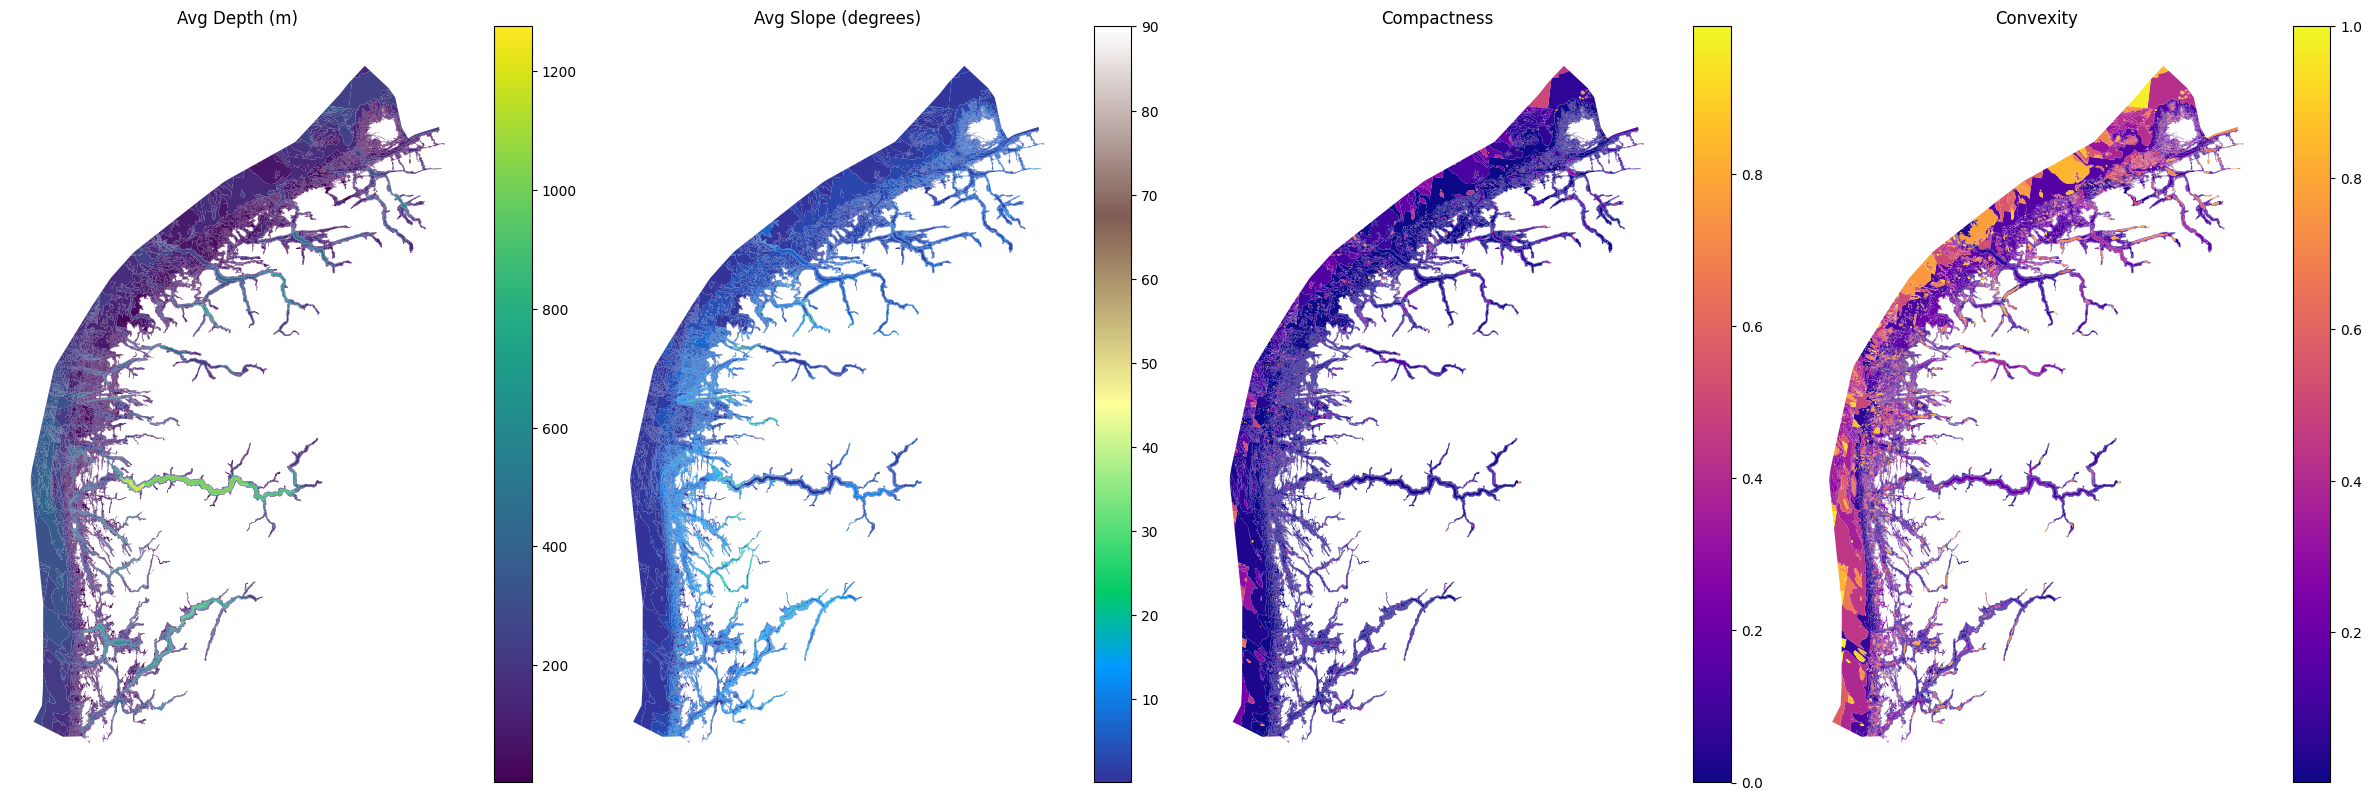

In [7]:
subkart.plot.terrain_features(gdf_sea_map)

## DEM 50

https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-50-meters-grid/67a3a191-49cc-45bc-baf0-eaaf7c513549

In [8]:
dem = subkart.sources.dem_data()

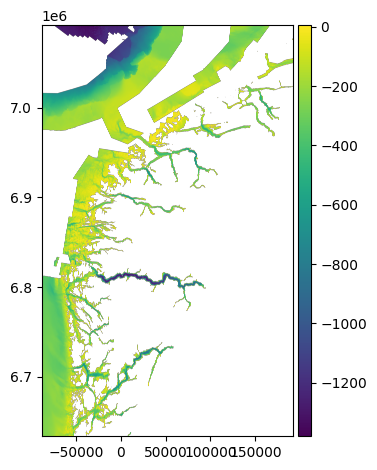

In [9]:
dem = dem.crop(bounds)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)
dem.plot()

### Wave exposure features



In [12]:
bolge = subkart.sources.bolge_exposure()


In [ ]:
bolge = bolge.crop(bounds)
bolge = subkart.utils.resample_dem(bolge, out_shape, transform, crs)
bolge.plot()

## Dataset for labels

In [10]:
gdf_bunn_full = gpd.read_parquet(
    "gs://niva-geodata/MarintNaturKart/results/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet"
)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape=out_shape, transform=transform)
del gdf_bunn_full

## Training

In [11]:
X, valid, out_shape, transform = subkart.features.build(
    dem, gdf_sea_map, bolge, valid_bunn, res=RESOLUTION, dtype=np.float32
)

Preparing sea_avg_depth...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/jovyan/marint-naturkart-niva/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing marine types...


Stacking feature arrays...


In [12]:
y = bunn_raster[valid]  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Baseline

Train a quick baseline for each model

In [13]:
baseline_models = [
    XGBClassifier(
        num_class=len(classes),
        n_estimators=300,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=2,
        tree_method="hist",
    ),
    #HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
]

score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - " f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline XGBClassifier - Train: 0.7635, Val: 0.7598


## Random Search

Search through hyperparameters for each model, this can take some time

In [14]:
is_random_search = False

if is_random_search:
    classifier = subkart.training.random_search(X_train, y_train, X_val, y_val, classes, class_weights)


In [15]:
is_xgb_random_search = False
if is_xgb_random_search:
    classifier, search_results = subkart.training.optimize_xgboost_hyperparameters(
        X_train, y_train, X_val, y_val, classes
    )

In [16]:
dump(classifier, subkart.utils.model_dir_path() / "classifier.joblib")

['/home/jovyan/marint-naturkart-niva/model/classifier.joblib']

sea_avg_depth: mean=0.077355, std=0.000521
sea_convexity: mean=0.077162, std=0.000426
dem_depth: mean=0.069450, std=0.000538
dem_curvature: mean=0.062816, std=0.000304
sea_compactness: mean=0.061759, std=0.000408
dem_slope: mean=0.051392, std=0.000392
sea_avg_slope: mean=0.042840, std=0.000253
beskyttet: mean=0.008588, std=0.000178
bølgeeksponert: mean=0.008122, std=0.000225
moderat_eksponert: mean=0.004599, std=0.000121
is_dem: mean=0.002635, std=0.000110


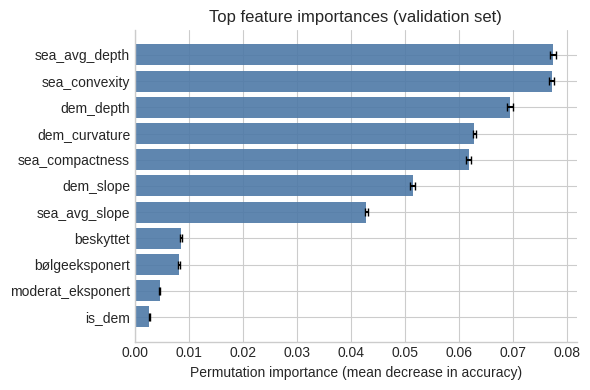

In [17]:
subkart.plot.feature_importance(classifier, X_val, y_val)

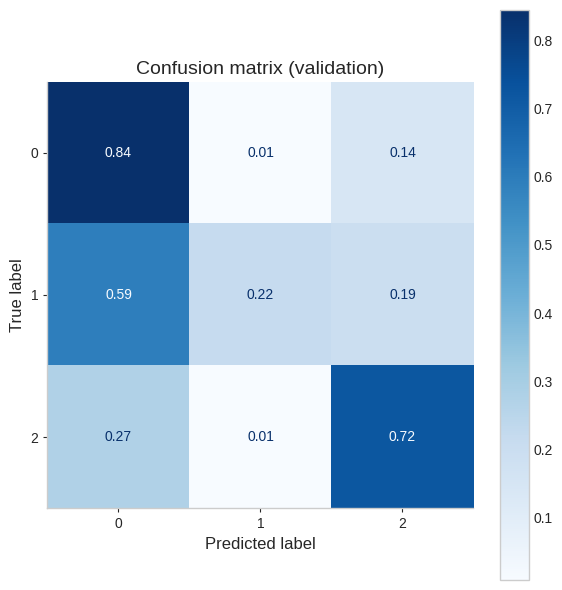

In [18]:
# Predict on validation set
y_val_pred = classifier.predict(X_val)

# Compute confusion matrix (normalized by true class)
cm = confusion_matrix(y_val, y_val_pred, labels=classes, normalize="true")

subkart.plot.confusion_matrix(cm, classes)

In [19]:
# Print classification report
print("Classification report (validation):")
report_dict = classification_report(
    y_val,
    y_val_pred,
    labels=classes,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T
report_df


Classification report (validation):


,precision,recall,f1-score,support
0,0.789773,0.844585,0.816260,324931.000000
1,0.600582,0.216312,0.318067,36230.000000
2,0.715877,0.718266,0.717070,188788.000000
accuracy,0.759832,0.759832,0.759832,0.759832
macro avg,0.702078,0.593055,0.617132,549949.000000
weighted avg,0.751942,0.759832,0.749389,549949.000000
